In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [132]:
df=pd.read_csv(r"C:\Users\SAMARTH\Downloads\Flight_Booking - Flight_Booking.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [133]:
#here Unnamed:0  is of no use removing it
df=df.drop(columns=['Unnamed: 0'])
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


##  **EDA**

In [134]:
df.shape

(300153, 11)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [136]:
df.isna().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [137]:
df.duplicated().sum()

531

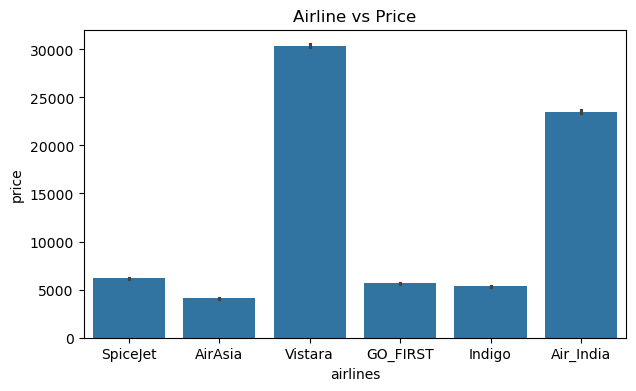

In [138]:
#checking the price with different airlines
plt.figure(figsize=(7,4))
sns.barplot(x=df['airline'],y=df['price'])
plt.title("Airline vs Price")
plt.xlabel("airlines")
plt.ylabel("price")
plt.show()

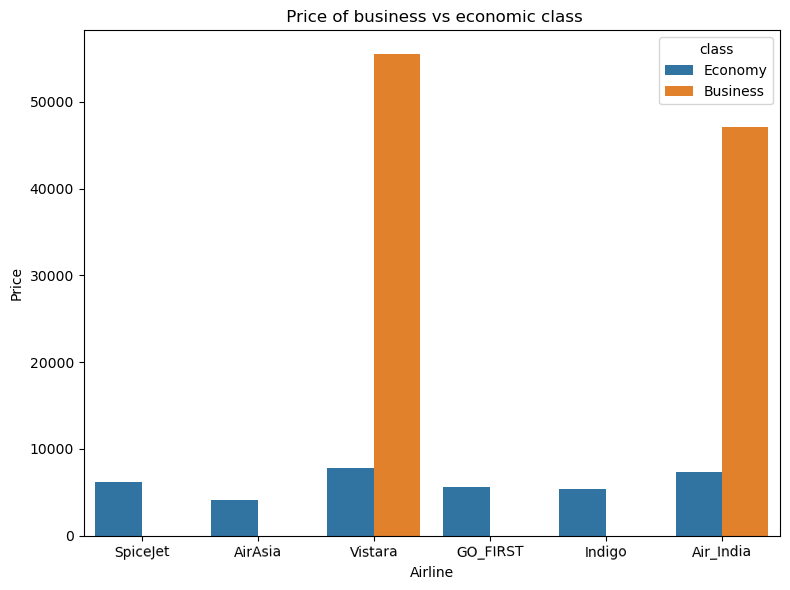

In [139]:
#price of business vs economic class of the each airline
plt.figure(figsize=(8,6))
sns.barplot(data=df,x='airline',y='price',hue='class',errorbar=None)
plt.title(" Price of business vs economic class")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.xticks(rotation=1) #used to rotate the names on x axis
plt.tight_layout()
plt.show()

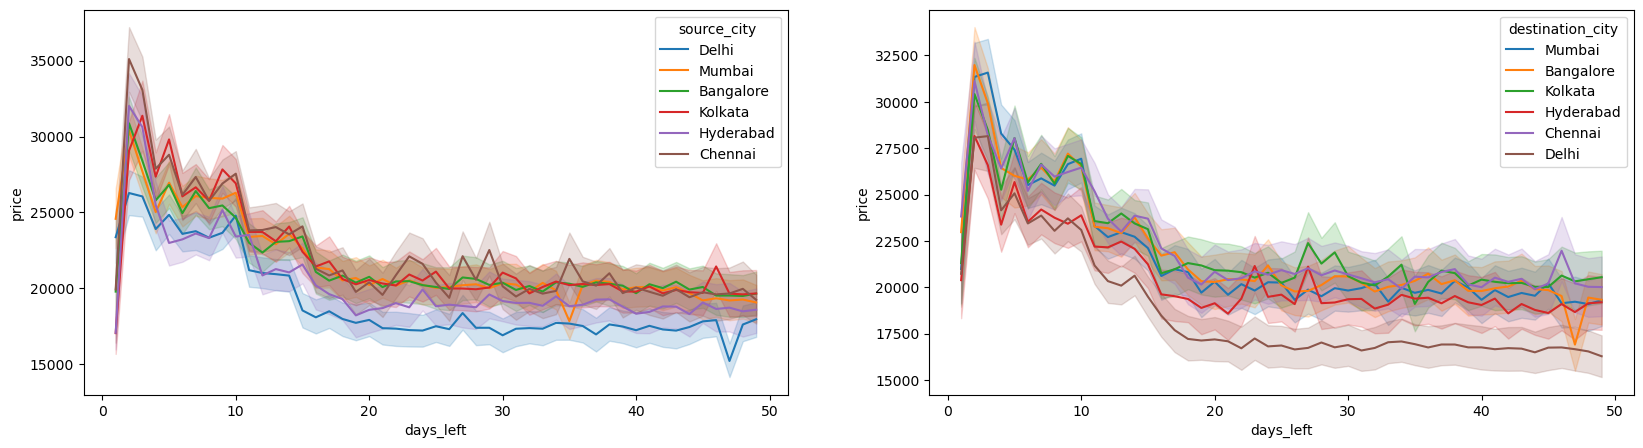

In [140]:
#range of price of flights with source and destination city according to days left 
fig, ax = plt.subplots(1,2, figsize =(20, 5))
sns. lineplot(x ='days_left', y ='price', hue ='source_city', data = df, ax = ax[0])
sns. lineplot(x = 'days_left', y ='price', hue ='destination_city', data = df, ax = ax[1])
plt.show()

In [141]:
from sklearn.preprocessing import LabelEncoder

In [142]:
le=LabelEncoder()

In [143]:
for i in df.columns:
    if df[i].dtype=='object':
        df[i]=le.fit_transform(df[i])

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  int32  
 1   flight            300153 non-null  int32  
 2   source_city       300153 non-null  int32  
 3   departure_time    300153 non-null  int32  
 4   stops             300153 non-null  int32  
 5   arrival_time      300153 non-null  int32  
 6   destination_city  300153 non-null  int32  
 7   class             300153 non-null  int32  
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int32(8), int64(2)
memory usage: 16.0 MB


In [145]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

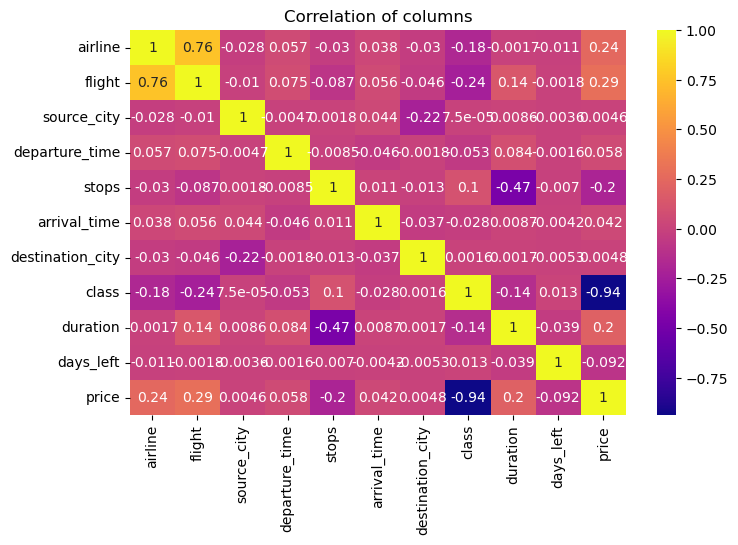

In [146]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(),annot=True,cmap='plasma') 
plt.title("Correlation of columns")
plt.show()

In [147]:
x = df.drop(columns=["price", "flight"]) #flight It's an ID column and adds noise.
y = df["price"]

In [148]:
x

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,4,2,2,2,5,5,1,2.17,1
1,4,2,1,2,4,5,1,2.33,1
2,0,2,1,2,1,5,1,2.17,1
3,5,2,4,2,0,5,1,2.25,1
4,5,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,5,1,4,0,2,3,0,10.08,49
300149,5,1,0,0,5,3,0,10.42,49
300150,5,1,1,0,5,3,0,13.83,49
300151,5,1,1,0,2,3,0,10.00,49


In [149]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [150]:
from sklearn.model_selection import train_test_split

In [151]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42) #splitting training and testing data

In [152]:
from sklearn.preprocessing import StandardScaler

In [153]:
scaler=StandardScaler()

In [154]:
x_scaled=scaler.fit_transform(x_train)
#We fit on X_train only so the mean and std come from training data alone.
#Fitting on the test data would leak information from it into training (data leakage).

In [155]:
x_scaled #scaled x_train

array([[-1.15009744,  0.81160707, -1.37873905, ...,  0.67246146,
         1.00173042, -1.47488258],
       [-0.05891224, -0.33003243, -1.37873905, ...,  0.67246146,
        -0.72463441, -0.95897275],
       [-1.15009744,  0.81160707, -1.37873905, ..., -1.48707407,
         1.24497828,  1.32577077],
       ...,
       [-1.15009744,  0.81160707,  1.47332728, ...,  0.67246146,
         0.20248744,  0.22024971],
       [-0.60450484,  0.81160707, -1.37873905, ...,  0.67246146,
        -0.53976604,  0.95726375],
       [-1.15009744,  0.81160707, -1.37873905, ...,  0.67246146,
         1.1059795 , -0.66416714]])

What is VIF :

VIF stands for Variance Inflation Factor.
It measures how strongly one feature is correlated with the other features in the dataset.
A VIF above 10 means serious multicollinearity, and 1 to 5 is considered fine.

Why we are doing it:

To detect multicollinearity, where features are redundant and carry the same information.
High multicollinearity makes linear regression coefficients unstable and hard to interpret.
Features with high VIF can be dropped or combined to make the model more reliable.

Where we use VIF :

We use VIF on the training features (X_train) after encoding, before training the model.
It is mainly used with linear models like Linear, Ridge and Lasso regression, where multicollinearity causes problems.
In this project, we check VIF to find redundant features (like stops and duration) and drop them if the value is above 10.

In [156]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [157]:
vif_data=pd.DataFrame()
vif_data['Feature']=x.columns
vif_values=[]

for i in range(len(x.columns)):
    vif=variance_inflation_factor(x_scaled,i)
    vif_values.append(vif)
vif_data['VIF']=vif_values

In [158]:
print(vif_data.sort_values("VIF", ascending=False)) 
#Result: no multicollinearity problem. Every VIF is below 5, and most are close to 1, so no feature needs to be dropped because of VIF.

            Feature       VIF
7          duration  1.319315
3             stops  1.297214
6             class  1.056260
1       source_city  1.055840
5  destination_city  1.055364
0           airline  1.041026
2    departure_time  1.015717
4      arrival_time  1.007887
8         days_left  1.002596


In [159]:
#creating model and training-using Linear Regression

In [160]:
from sklearn.linear_model import LinearRegression

In [161]:
model=LinearRegression()

In [162]:
model.fit(x_train,y_train)

LinearRegression()

In [163]:
y_pred=model.predict(x_test)

In [164]:
y_pred #this is our predicted data

array([ 4585.88050973, 52842.07707275,  7877.98018389, ...,
        5848.96550018, -1498.06191818, 58762.40634474])

In [165]:
from sklearn.metrics import *

In [166]:
print("R2 Score",r2_score(y_test,y_pred)*100)
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score 90.4554350718816
MAE : 4624.994868016886
RMSE: 7014.3096804833185


R² = 90.46%: the model explains about 90% of the variation in ticket prices. The remaining 10% comes from factors it can't capture.  

MAE = ₹4,625: the average difference between the predicted and actual price across all test flights is about ₹4,625.   lower the mse good model

RMSE = ₹7,014: also a measure of the average difference, but it gives extra weight to large mistakes. It is higher than MAE because a few predictions, mostly expensive Business fares, are far from the actual price.

### Now using DecisionTreeRegressor

In [167]:
from sklearn.tree import DecisionTreeRegressor

In [168]:
model1=DecisionTreeRegressor(random_state=42)

In [169]:
model1.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [170]:
y2_pred=model1.predict(x_test)

In [171]:
print(r2_score(y_test,y2_pred)*100)
print(mean_absolute_error(y_test,y2_pred))
print(np.sqrt(mean_squared_error(y_test,y2_pred)))

97.56894563052411
1171.2941896686712
3540.007674493055


### Now using RandomForestRegressor

In [172]:
from sklearn.ensemble import RandomForestRegressor

In [173]:
model2=RandomForestRegressor(n_estimators=50,min_samples_leaf=3,n_jobs=-1,random_state=42) #n_jobs=-1 sets all core for training and trains faster

In [174]:
model2.fit(x_train,y_train)

RandomForestRegressor(min_samples_leaf=3, n_estimators=50, n_jobs=-1,
                      random_state=42)

In [175]:
y3_pred=model2.predict(x_test)

In [176]:
print(r2_score(y_test,y3_pred)*100)
print(mean_absolute_error(y_test,y3_pred))
print(np.sqrt(mean_squared_error(y_test,y3_pred)))

98.58020011495896
1135.9055115182366
2705.331167812513


### Random Forest performs best on all three metrics (R² 98.58%, MAE ₹1,136, RMSE ₹2,705). It beats Linear Regression because it captures non-linear patterns in the data, and it beats a single Decision Tree because averaging many trees reduces overfitting.

### Overfitting Check (Random Forest)

**What:** Compared the model's R² on the training data with its R² on the test data.

**Why:** Overfitting happens when a model memorizes the training data and performs worse on new data. A large gap between train and test scores signals this.

**How:**
1. Predicted on `x_train` with the already trained model (no re-fitting).
2. Calculated train R² using `y_train`.
3. Compared it with the test R² (98.58%).

**Interpretation:** A small gap means the model generalizes well. A large gap means overfitting.

In [177]:
y_train_pred = model2.predict(x_train) #here passing x_train intead of x_test
train_r2 = r2_score(y_train, y_train_pred) * 100 #train accuracy


In [178]:
test_r2 = r2_score(y_test, y3_pred) * 100 #this was our test accuracy

print("Train R2 (%):", train_r2) #printing comparing them and finding thier gap
print("Test R2  (%):", test_r2)
print("Gap:", train_r2 - test_r2)

Train R2 (%): 99.26969263268629
Test R2  (%): 98.58020011495896
Gap: 0.6894925177273308


**Result:** Train R² = 99.27%, Test R² = 98.58%, gap ≈ 0.69.

**Conclusion:** The gap is small, so Random Forest generalizes well and is not overfitting.

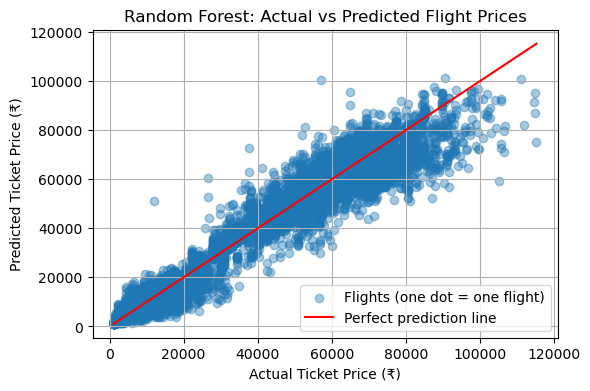

In [179]:
import matplotlib.pyplot as plt

y_rf_pred = model2.predict(x_test)   # Random Forest predictions on test data

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_rf_pred, alpha=0.4, label="Flights (one dot = one flight)")

# red line = perfect prediction (predicted = actual)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", label="Perfect prediction line")

plt.xlabel("Actual Ticket Price (₹)")
plt.ylabel("Predicted Ticket Price (₹)")
plt.title("Random Forest: Actual vs Predicted Flight Prices")
plt.legend()
plt.grid(True)
plt.show()

**Actual vs Predicted plot (Random Forest):** Most points lie close to the perfect-prediction line, confirming high accuracy. Errors are small for low-priced (Economy) flights and grow for high-priced (Business) flights, with a few outliers.

In [180]:
model2.feature_importances_ #imp of each column

array([0.01078259, 0.01066939, 0.0039204 , 0.00182864, 0.00434918,
       0.00940075, 0.88530307, 0.05822424, 0.01552174])

In [181]:
importance=pd.Series(model2.feature_importances_,index=x.columns).sort_values(ascending=False)
importance

class               0.885303
duration            0.058224
days_left           0.015522
airline             0.010783
source_city         0.010669
destination_city    0.009401
arrival_time        0.004349
departure_time      0.003920
stops               0.001829
dtype: float64

#### Feature Importance (Random Forest)

**What:** Found which features influence flight price the most, using the trained Random Forest's `feature_importances_`.

**Why:** It shows which inputs the model relies on to predict price, which helps explain the results and understand the data.

**How:**
1. Took the importance scores from the trained model (`model2.feature_importances_`).
2. Paired each score with its feature name using `x.columns`.
3. Sorted the features from highest to lowest importance.

**Interpretation:** Features with higher scores have a bigger effect on the predicted price.

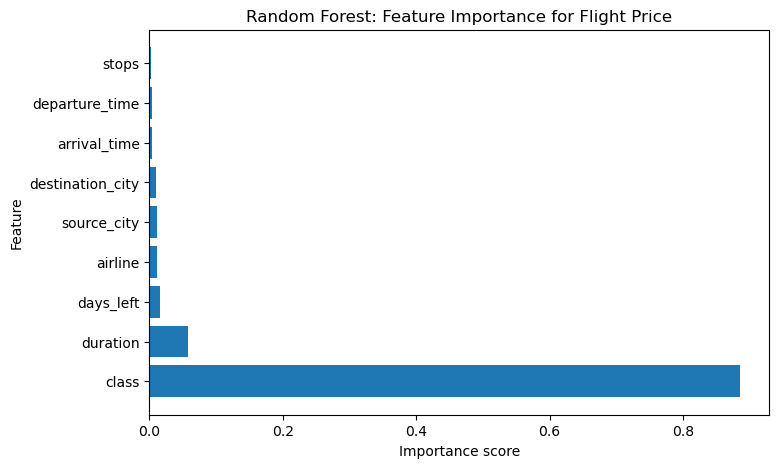

In [182]:
plt.figure(figsize=(8, 5))
plt.barh(importance.index, importance.values)
plt.xlabel("Importance score")
plt.ylabel("Feature")
plt.title("Random Forest: Feature Importance for Flight Price")
plt.show()

**Result:** The top features are __, __ and __.  

**Meaning:** Business class costs far more than Economy, longer flights cost more, and prices rise as the departure date gets closer (fewer days left).

# Conclusion
Three models were compared for flight price prediction: Linear Regression, Decision Tree and Random Forest.
Random Forest performed best (R² 98.58%, MAE ₹1,136, RMSE ₹2,705).
The train-test R² gap is about 0.69 points, so the model is not overfitting.
Key price drivers: class (about 88.5% importance), duration (5.8%) and days left (1.6%).

In [183]:
#now saving the model using joblib

In [184]:
import joblib
joblib.dump(model2, 'rf_model.pkl', compress=3)

['rf_model.pkl']

In [185]:
import os
print(os.getcwd())

C:\Users\SAMARTH


In [186]:
import os
print(round(os.path.getsize('rf_model.pkl') / 1e6, 1), "MB")

54.2 MB


In [187]:
#saving the columns for input

In [188]:
import json
json.dump(list(x.columns), open("columns.json", "w"))

In [189]:
raw=pd.read_csv(r"C:\Users\SAMARTH\Downloads\Flight_Booking - Flight_Booking.csv") # original data, before encoding
cat_cols = ["airline", "source_city", "departure_time", "stops",
            "arrival_time", "destination_city", "class"]

encoders = {col: LabelEncoder().fit(raw[col]) for col in cat_cols}
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']

In [193]:
raw.head(100)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,Vistara,UK-737,Delhi,Afternoon,one,Night,Mumbai,Economy,7.58,1,17610
96,96,Air_India,AI-762,Delhi,Night,one,Night,Mumbai,Economy,23.83,1,17295
97,97,Vistara,UK-673,Delhi,Afternoon,one,Evening,Mumbai,Economy,5.00,1,17663
98,98,Air_India,AI-839,Delhi,Night,one,Night,Mumbai,Economy,26.50,1,18030


In [1]:
import sklearn; print(sklearn.__version__)

1.5.1
